In [ ]:
!pip install datasets
!pip install tqdm

from sklearn.metrics.pairwise import cosine_similarity
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import login

import json
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np
import re
import seaborn as sns
from scipy.stats import norm


In [ ]:
ds_neg = load_dataset("Ramitha/squad1.1-minimum-200-negative-expanded-results", split="rawcases")
ds_pos = load_dataset("Ramitha/squad1.1-minimum-200-positive-expanded-results", split="rawcases")

In [3]:
df_neg = ds_neg.to_pandas()
df_pos = ds_pos.to_pandas()

models = [
    "original",
    "smollm2-1.7b",
    "qwen-7b",
    "phi3-mini-3.8b"
]

dfs_neg = {m: df_neg[df_neg["expansion_model"] == m].copy() for m in models}
dfs_pos = {m: df_pos[df_pos["expansion_model"] == m].copy() for m in models}

for m in models:
    print(f"[NEG] {m}: {len(dfs_neg[m])}")
    print(f"[POS] {m}: {len(dfs_pos[m])}")

[NEG] original: 200
[POS] original: 200
[NEG] smollm2-1.7b: 200
[POS] smollm2-1.7b: 200
[NEG] qwen-7b: 200
[POS] qwen-7b: 200
[NEG] phi3-mini-3.8b: 200
[POS] phi3-mini-3.8b: 200


In [4]:
dfs_pos["original"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 62 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   title                                              200 non-null    object 
 1   snippet                                            200 non-null    object 
 2   question                                           200 non-null    object 
 3   answer                                             200 non-null    object 
 4   word_count                                         200 non-null    object 
 5   category                                           200 non-null    object 
 6   answerGenerated                                    200 non-null    object 
 7   number                                             200 non-null    object 
 8   expansion_model                                    200 non-null    object 
 9   gold_standard_c

SAMPLING AND SLOPE VISUALISATION

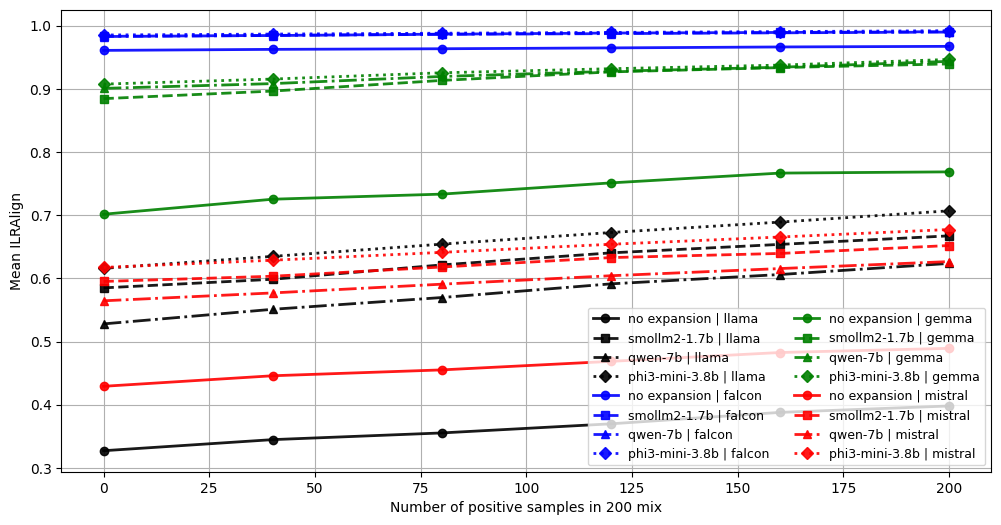

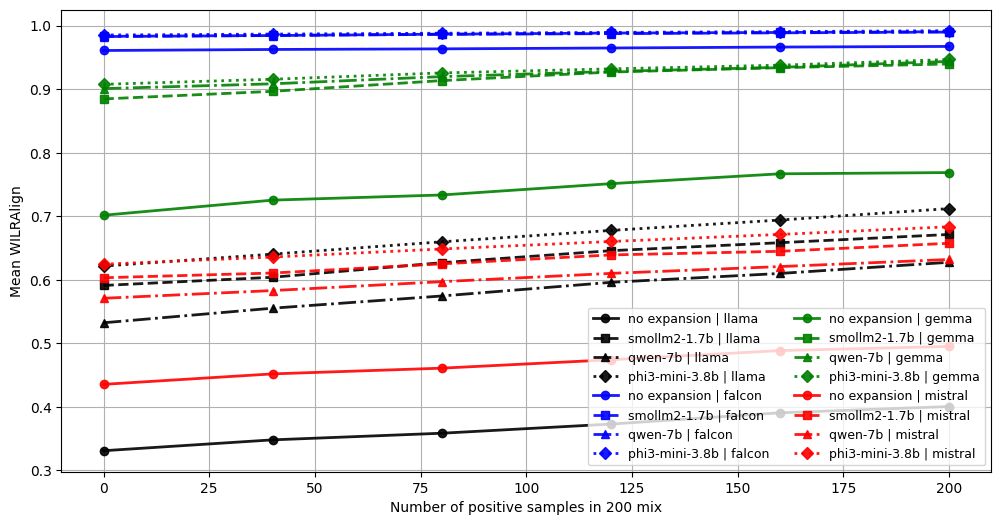

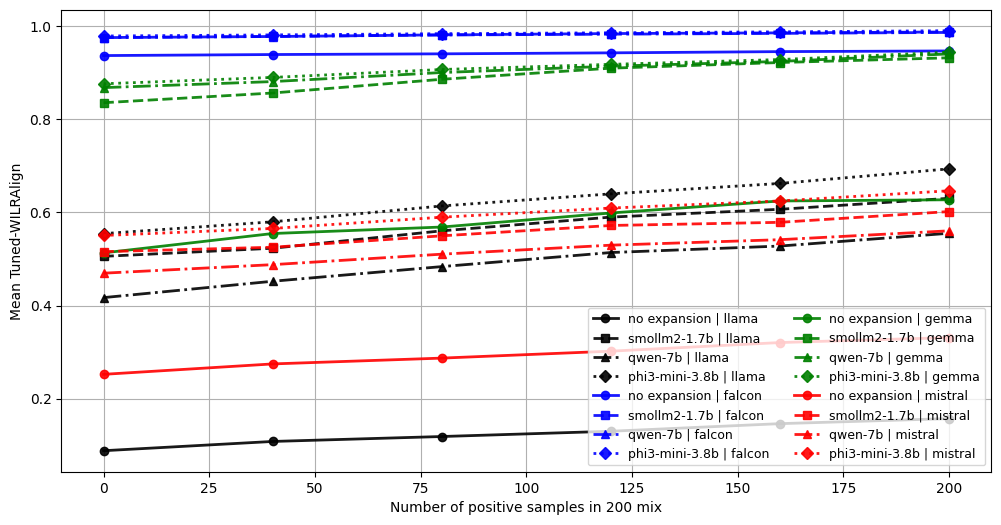

In [5]:
SEED = 42
mixtures = [0, 40, 80, 120, 160, 200]

exp_models = [
    "original",
    "smollm2-1.7b",
    "qwen-7b",
    "phi3-mini-3.8b"
]

base_models = ["llama", "falcon", "gemma", "mistral"]

def fix_numeric(df):
    df = df.copy()
    cols = []
    for b in base_models:
        cols += [
            f"ILRAlign_{b}",
            f"WILRAlign_{b}",
            f"WILRAlign_tuned_{b}"
        ]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

dfs_pos = {m: fix_numeric(dfs_pos[m]) for m in exp_models}
dfs_neg = {m: fix_numeric(dfs_neg[m]) for m in exp_models}

def build_curve(df_pos, df_neg, col):
    results = []
    for p in mixtures:
        n_p = p
        n_n = 200 - p
        pos_sample = df_pos.sample(n=n_p, random_state=SEED)
        used_ids = set(pos_sample["number"])
        neg_pool = df_neg[~df_neg["number"].isin(used_ids)]
        neg_sample = neg_pool.sample(n=n_n, random_state=SEED)
        combined = pd.concat([pos_sample, neg_sample], ignore_index=True)
        results.append(combined[col].mean())
    return results

def plot_chart(prefix):
    plt.figure(figsize=(12, 6))
    exp_styles = {
        "original": ("o", "-"),
        "smollm2-1.7b": ("s", "--"),
        "qwen-7b": ("^", "-."),
        "phi3-mini-3.8b": ("D", ":")
    }
    colors = {
        "llama": "black",
        "falcon": "blue",
        "gemma": "green",
        "mistral": "red"
    }
    for base in base_models:
        for m in exp_models:
            df_pos = dfs_pos[m]
            df_neg = dfs_neg[m]
            col = f"{prefix}_{base}"
            curve = build_curve(df_pos, df_neg, col)
            marker, linestyle = exp_styles[m]
            label_name = "no expansion" if m == "original" else m
            plt.plot(
                mixtures,
                curve,
                marker=marker,
                linestyle=linestyle,
                linewidth=2,
                label=f"{label_name} | {base}",
                color=colors[base],
                alpha=0.9
            )
    plt.xlabel("Number of positive samples in 200 mix")
    if prefix == "ILRAlign":
        ylabel = "Mean ILRAlign"
    elif prefix == "WILRAlign":
        ylabel = "Mean WILRAlign"
    elif prefix == "WILRAlign_tuned":
        ylabel = "Mean Tuned-WILRAlign"
    else:
        ylabel = prefix
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend(loc="lower right", ncol=2, fontsize=9)
    plt.show()

plot_chart("ILRAlign")
plot_chart("WILRAlign")
plot_chart("WILRAlign_tuned")

ANALYSING MIN-MAX PERCENTAGE DIFFERENCE

In [6]:
SEED = 42

exp_models = [
    "original",
    "smollm2-1.7b",
    "qwen-7b",
    "phi3-mini-3.8b"
]

base_models = ["llama", "falcon", "gemma", "mistral"]

def fix_numeric(df):
    df = df.copy()

    cols = ["gold_standard_cos"]

    for b in base_models:
        cols += [
            f"ILRAlign_{b}",
            f"WILRAlign_{b}",
            f"WILRAlign_tuned_{b}"
        ]

    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

dfs_pos = {m: fix_numeric(dfs_pos[m]) for m in exp_models}
dfs_neg = {m: fix_numeric(dfs_neg[m]) for m in exp_models}

def compute_diff(df_pos, df_neg, col):
    pos_sample = df_pos.sample(n=100, random_state=SEED)
    neg_sample = df_neg.sample(n=100, random_state=SEED)

    return pos_sample[col].mean() - neg_sample[col].mean()

rows = []

for m in exp_models:
    for base in base_models:

        df_pos = dfs_pos[m]
        df_neg = dfs_neg[m]

        rows.append({
            "exp_model": m,
            "base_model": base,
            "ILRAlign": compute_diff(df_pos, df_neg, f"ILRAlign_{base}"),
            "WILRAlign": compute_diff(df_pos, df_neg, f"WILRAlign_{base}"),
            "WILRAlign_tuned": compute_diff(df_pos, df_neg, f"WILRAlign_tuned_{base}")
        })

df_diff = pd.DataFrame(rows)

metric_cols = ["ILRAlign", "WILRAlign", "WILRAlign_tuned"]

df_diff[metric_cols] = df_diff[metric_cols] * 100
df_diff[metric_cols] = df_diff[metric_cols].round(2)
df_diff = df_diff.sort_values(by=["base_model", "exp_model"]).reset_index(drop=True)

print(df_diff)


         exp_model base_model  ILRAlign  WILRAlign  WILRAlign_tuned
0         original     falcon      0.61       0.61             0.93
1   phi3-mini-3.8b     falcon      0.71       0.71             1.16
2          qwen-7b     falcon      0.65       0.65             0.99
3     smollm2-1.7b     falcon      0.67       0.67             1.05
4         original      gemma      6.76       6.77            11.41
5   phi3-mini-3.8b      gemma      4.06       4.06             6.95
6          qwen-7b      gemma      3.61       3.61             6.07
7     smollm2-1.7b      gemma      5.86       5.85            10.25
8         original      llama      6.21       6.15             5.58
9   phi3-mini-3.8b      llama      9.33       9.22            13.86
10         qwen-7b      llama      8.87       8.77            11.88
11    smollm2-1.7b      llama      6.83       6.68            10.30
12        original    mistral      5.52       5.61             7.45
13  phi3-mini-3.8b    mistral      5.89       5.

SLOPE ANALYSIS

In [7]:
SEED = 42
mixtures = [0, 40, 80, 120, 160, 200]

exp_models = [
    "original",
    "smollm2-1.7b",
    "qwen-7b",
    "phi3-mini-3.8b"
]

base_models = ["llama", "falcon", "gemma", "mistral"]

def fix_numeric(df):
    df = df.copy()

    cols = []

    for b in base_models:
        cols += [
            f"ILRAlign_{b}",
            f"WILRAlign_{b}",
            f"WILRAlign_tuned_{b}"
        ]

    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df
dfs_pos = {m: fix_numeric(dfs_pos[m]) for m in exp_models}
dfs_neg = {m: fix_numeric(dfs_neg[m]) for m in exp_models}

def build_curve(df_pos, df_neg, col):
    results = []
    for p in mixtures:
        n_p = p
        n_n = 200 - p
        # sample positives
        pos_sample = df_pos.sample(n=n_p, random_state=SEED)
        used_ids = set(pos_sample["number"])
        neg_pool = df_neg[~df_neg["number"].isin(used_ids)]
        neg_sample = neg_pool.sample(n=n_n, random_state=SEED)
        combined = pd.concat([pos_sample, neg_sample], ignore_index=True)
        results.append(combined[col].mean())
    return results

def compute_curve_slope(curve, x_vals):
    x = np.array(x_vals)
    y = np.array(curve)
    if len(x) < 2:
        return np.nan
    slope = np.polyfit(x, y, 1)[0]
    return slope

rows = []
for m in exp_models:
    for base in base_models:
        df_pos = dfs_pos[m]
        df_neg = dfs_neg[m]

        # --- ILRAlign ---
        curve_ilr = build_curve(df_pos, df_neg, f"ILRAlign_{base}")
        slope_ilr = compute_curve_slope(curve_ilr, mixtures)

        # --- WILRAlign ---
        curve_wilr = build_curve(df_pos, df_neg, f"WILRAlign_{base}")
        slope_wilr = compute_curve_slope(curve_wilr, mixtures)

        # --- Tuned ---
        curve_tuned = build_curve(df_pos, df_neg, f"WILRAlign_tuned_{base}")
        slope_tuned = compute_curve_slope(curve_tuned, mixtures)

        rows.append({
            "exp_model": m,
            "base_model": base,
            "ILRAlign_slope": slope_ilr,
            "WILRAlign_slope": slope_wilr,
            "WILRAlign_tuned_slope": slope_tuned
        })

df_slopes = pd.DataFrame(rows)

metric_cols = [
    "ILRAlign_slope",
    "WILRAlign_slope",
    "WILRAlign_tuned_slope"
]

df_slopes[metric_cols] = df_slopes[metric_cols] * 100
df_slopes[metric_cols] = df_slopes[metric_cols].round(4)
df_slopes = df_slopes.sort_values(
    by=["base_model", "exp_model"]
).reset_index(drop=True)

df_slopes

,exp_model,base_model,ILRAlign_slope,WILRAlign_slope,WILRAlign_tuned_slope
0,original,falcon,0.0032,0.0032,0.0050
1,phi3-mini-3.8b,falcon,0.0034,0.0034,0.0056
2,qwen-7b,falcon,0.0035,0.0035,0.0055
3,smollm2-1.7b,falcon,0.0038,0.0038,0.0061
4,original,gemma,0.0341,0.0341,0.0579
5,phi3-mini-3.8b,gemma,0.0191,0.0192,0.0333
6,qwen-7b,gemma,0.0214,0.0214,0.0361
7,smollm2-1.7b,gemma,0.0286,0.0286,0.0502
8,original,llama,0.0356,0.0350,0.0336
9,phi3-mini-3.8b,llama,0.0455,0.0451,0.0692


In [8]:
df_original = df_slopes[df_slopes['exp_model'] == 'original']
df_others = df_slopes[df_slopes['exp_model'] != 'original']

cols = [
    'ILRAlign_slope',
    'WILRAlign_slope',
    'WILRAlign_tuned_slope'
]

original_avg = df_original[cols].mean()
others_avg = df_others[cols].mean()


percent_improvement = ((others_avg - original_avg) / original_avg) * 100
print("Original average:\n", original_avg)
print("\nOthers average:\n", others_avg)
print("\nPercentage improvement (%):\n", percent_improvement)

Original average:
 ILRAlign_slope           0.0258
WILRAlign_slope          0.0256
WILRAlign_tuned_slope    0.0339
dtype: float64

Others average:
 ILRAlign_slope           0.025508
WILRAlign_slope          0.025167
WILRAlign_tuned_slope    0.039642
dtype: float64

Percentage improvement (%):
 ILRAlign_slope           -1.130491
WILRAlign_slope          -1.692708
WILRAlign_tuned_slope    16.937070
dtype: float64


In [9]:

without_expansion = df_slopes[df_slopes['exp_model'] == 'original']
with_expansion = df_slopes[df_slopes['exp_model'] != 'original']


cols = [
    'ILRAlign_slope',
    'WILRAlign_slope',
    'WILRAlign_tuned_slope'
]

without_expansion_mean = without_expansion[cols].mean().mean()
with_expansion_mean = with_expansion[cols].mean().mean()

percentage_improvement = (
    (with_expansion_mean - without_expansion_mean)
    / without_expansion_mean
) * 100

print(f"Without expansion mean: {without_expansion_mean:.4f}")
print(f"With expansion mean: {with_expansion_mean:.4f}")
print(f"Percentage improvement: {percentage_improvement:.2f}%")

Without expansion mean: 0.0284
With expansion mean: 0.0301
Percentage improvement: 5.88%
